# Tema 1 IA - Introducere în Machine Learning

_Istrate Alexandru-Daniel, grupa 334CA_

## 0. Citirea datelor

In [1]:
# !pip install pandas numpy matplotlib seaborn
# !pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier

In [2]:
train_path = './input/CA_OUALD_train.csv'
test_path = './input/CA_OUALD_test.csv'


train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_split, validate_split = train_test_split(train_df, test_size=0.2, random_state=42)

kaggle_class_df = pd.read_csv('./input/CA_clasif_private_test.csv')
kaggle_reg_df = pd.read_csv('./input/CA_reg_private_test.csv')

## 1. Explorarea datelor 

### 1.1. Tipuri de atribute si plaja de valori

,count,mean,std,min,25%,50%,75%,max
studied_credits,15041.0,80.72,37.36,30.0,60.00,60.00,120.00,430.0
mean_score_early,15013.0,74.35,17.19,0.0,66.67,78.33,86.67,100.0


,count,unique
highest_education,15041,5


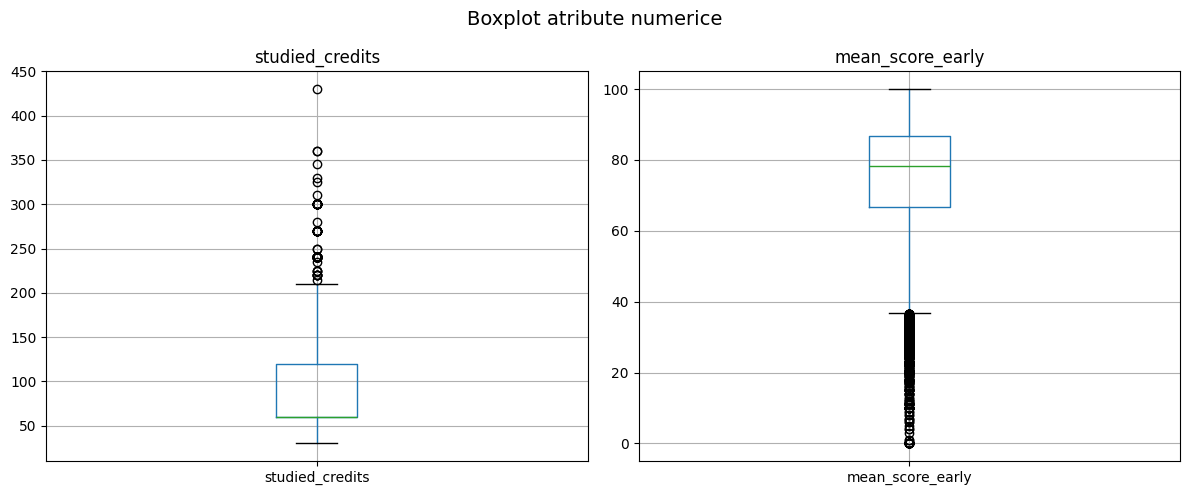

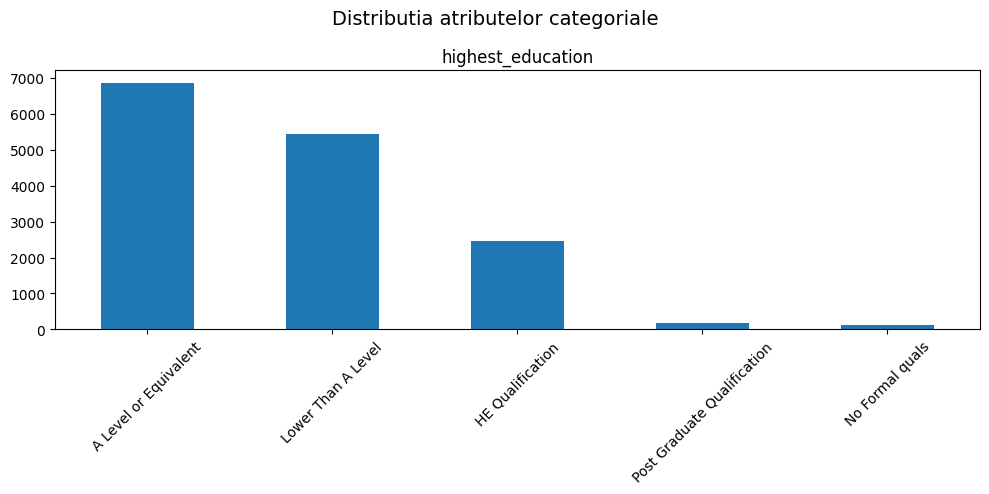

In [3]:
# Despart coloanele numerice de cele categoriale
numeric_cols = train_split.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('final_coursework_score')

categorical_cols = train_split.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
categorical_cols.remove('final_result')

# Stabilesc coloanele pe care vreau sa le analizez
analizing_cols = ['studied_credits', 'highest_education', 'mean_score_early']

# Extrag datele cerute
numeric_stats = {}
categorical_stats = {}

for atr in analizing_cols:
    if atr in numeric_cols:
        numeric_stats[atr] = train_split[atr].describe().round(2).to_frame().T
    elif atr in categorical_cols:
        categorical_stats[atr] = {
            'count': train_split[atr].count(),
            'unique': train_split[atr].nunique()
        }

# Afisez rezultatele sub forma de tabele
numeric_stats = pd.concat(numeric_stats.values())
display(numeric_stats)

categorical_stats = pd.DataFrame(categorical_stats).T
display(categorical_stats)

# Boxplot pentru atributele numerice
numeric_analizing = [col for col in analizing_cols if col in numeric_cols]
fig, axes = plt.subplots(1, len(numeric_analizing), figsize=(12, 5))

if len(numeric_analizing) == 1:
    axes = [axes]

for i, atr in enumerate(numeric_analizing):
    train_split.boxplot(column=atr, ax=axes[i])
    axes[i].set_title(atr)
    axes[i].set_xlabel('')

plt.suptitle('Boxplot atribute numerice', fontsize=14)
plt.tight_layout()
plt.show()

# Histograma pentru atributele categoriale
categorical_analizing = [col for col in analizing_cols if col in categorical_cols]

fig, axes = plt.subplots(1, len(categorical_analizing), figsize=(10, 5))

if len(categorical_analizing) == 1:
    axes = [axes]

for i, atr in enumerate(categorical_analizing):
    unique_vals = train_split[atr].unique()
    
    value_counts = train_split[atr].value_counts()
    
    value_counts.plot(kind='bar', ax=axes[i], width=0.5)
    axes[i].set_title(atr)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distributia atributelor categoriale', fontsize=14)
plt.tight_layout()
plt.show()

### 1.2. Echilibrul de clase

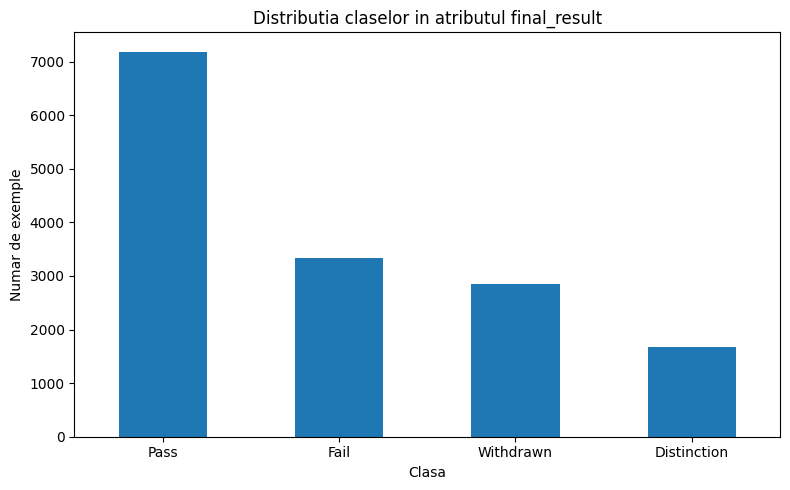

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

class_counts = train_split['final_result'].value_counts()
class_counts.plot(kind='bar', ax=ax, width=0.5)

ax.set_title('Distributia claselor in atributul final_result')
ax.set_xlabel('Clasa')
ax.set_ylabel('Numar de exemple')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 1.3. Corelatii intre atribute

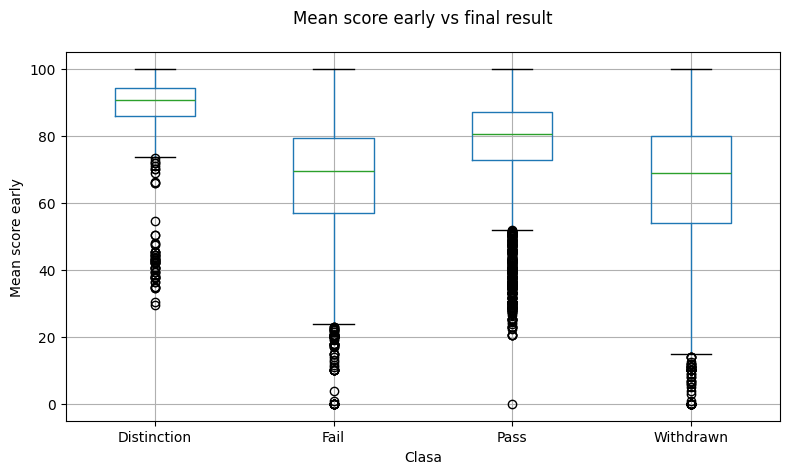

In [5]:
# Numeric + sarcina de clasificare
fig, ax = plt.subplots(figsize=(8, 5))

train_split.boxplot(column='mean_score_early', by='final_result', ax=ax)

ax.set_title('Mean score early vs final result\n')
ax.set_xlabel('Clasa')
ax.set_ylabel('Mean score early')
plt.suptitle('')
plt.tight_layout()
plt.show()

Tabel de contingenta:


final_result,Distinction,Fail,Pass,Withdrawn
highest_education,,,,
A Level or Equivalent,858,1359,3472,1174
HE Qualification,428,392,1236,391
Lower Than A Level,329,1526,2358,1225
No Formal quals,5,32,49,32
Post Graduate Qualification,53,21,70,31



Chi2: 548.7185
P-value: 0.0000
Grade de libertate: 12


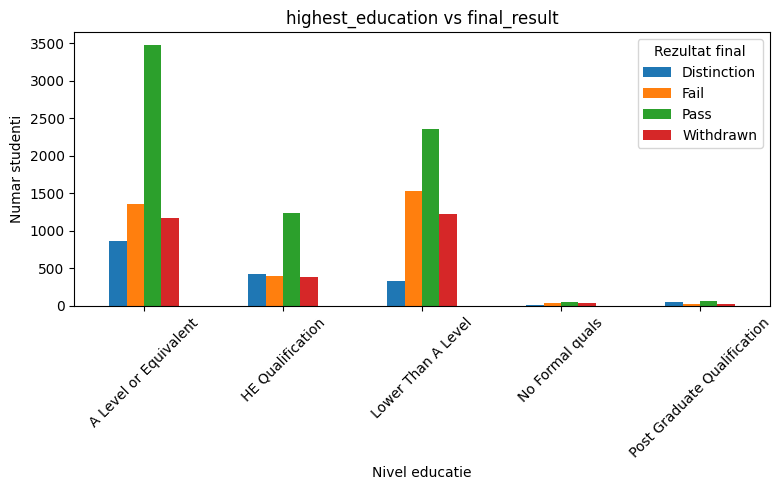

In [6]:
# Categorial + sarcina de clasificare
contingency_table = pd.crosstab(train_split['highest_education'], train_split['final_result'])
print("Tabel de contingenta:")
display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi2: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Grade de libertate: {dof}")

fig, ax = plt.subplots(figsize=(8, 5))
contingency_table.plot(kind='bar', ax=ax, width=0.5)

ax.set_title('highest_education vs final_result')
ax.set_xlabel('Nivel educatie')
ax.set_ylabel('Numar studenti')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Rezultat final')

plt.tight_layout()
plt.show()

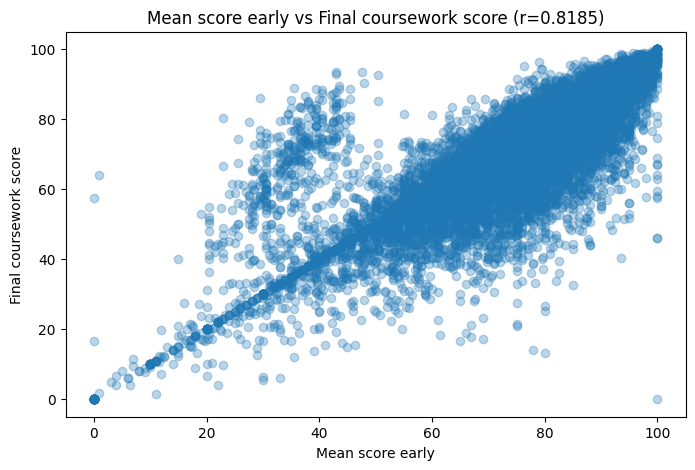

In [7]:
# Numeric + sarcina de regresie - corelatie Pearson
correlation = train_split['mean_score_early'].corr(train_split['final_coursework_score'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train_split['mean_score_early'], train_split['final_coursework_score'], alpha=0.3)
ax.set_xlabel('Mean score early')
ax.set_ylabel('Final coursework score')
ax.set_title(f'Mean score early vs Final coursework score (r={correlation:.4f})')
plt.show()

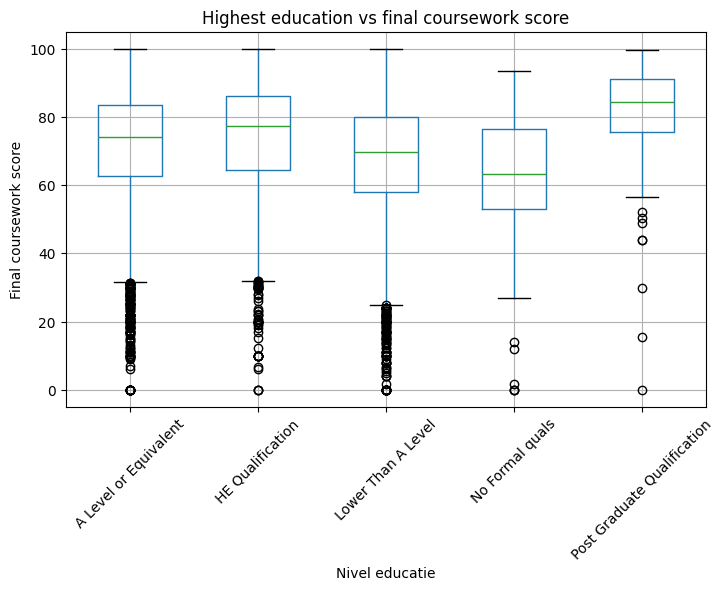

In [8]:
# Categorial + sarcina de regresie
fig, ax = plt.subplots(figsize=(8, 5))

train_split.boxplot(column='final_coursework_score', by='highest_education', ax=ax)

ax.set_title('Highest education vs final coursework score')
ax.set_xlabel('Nivel educatie')
ax.set_ylabel('Final coursework score')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

## 2. Preprocesarea datelor

### 2.1. Encodare ordinala

In [9]:
# Encodare ordinala a variabilei clicks_freq_init
freq_map = {'low': 0, 'mid': 1, 'high': 2}
for df in [train_split, validate_split, test_df, kaggle_class_df, kaggle_reg_df]:
    df['clicks_freq_init'] = df['clicks_freq_init'].map(freq_map)

### 2.2. Eliminarea data leakage

In [10]:
# Modelul gaseste o "scurtatura" in a prezice clasa Withdrawn prin coloana date_unregistration => data leakage
cols_to_drop = ['date_unregistration']
train_split = train_split.drop(columns=cols_to_drop, errors='ignore')
validate_split = validate_split.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')
kaggle_class_df = kaggle_class_df.drop(columns=cols_to_drop, errors='ignore')
kaggle_reg_df = kaggle_reg_df.drop(columns=cols_to_drop, errors='ignore')

if 'date_unregistration' in numeric_cols:
    numeric_cols.remove('date_unregistration')

### 2.3. Tratarea valorilor lipsa

In [11]:
# Analizam care este procentul de date lipsa pentru fiecare atribut
missing = train_split.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_split) * 100).round(2)

print(pd.DataFrame({
    'Valori lipsa': missing, 
    'Procent (%)': missing_pct
}))

                           Valori lipsa  Procent (%)
clicks_glossary                    4619        30.71
clicks_externalquiz                4438        29.51
imd_band                            626         4.16
clicks_ouelluminate                  50         0.33
refs_forumng                         50         0.33
clicks_url                           50         0.33
clicks_subpage                       50         0.33
clicks_sharedsubpage                 50         0.33
clicks_resource                      50         0.33
clicks_repeatactivity                50         0.33
clicks_quiz                          50         0.33
clicks_questionnaire                 50         0.33
clicks_page                          50         0.33
clicks_ouwiki                        50         0.33
clicks_oucontent                     50         0.33
clicks_oucollaborate                 50         0.33
clicks_htmlactivity                  50         0.33
clicks_homepage                      50       

In [12]:
# Fac imputare pentru mean_score_early
imputer = SimpleImputer(strategy='median')

train_split['mean_score_early'] = imputer.fit_transform(
    train_split[['mean_score_early']])

validate_split['mean_score_early'] = imputer.transform(
    validate_split[['mean_score_early']])

test_df['mean_score_early'] = imputer.transform(
    test_df[['mean_score_early']])

kaggle_class_df['mean_score_early'] = imputer.transform(
    kaggle_class_df[['mean_score_early']])

kaggle_reg_df['mean_score_early'] = imputer.transform(
    kaggle_reg_df[['mean_score_early']])

# Fac imputarea celorlalte atribute pentru imbunatatirea performantelor modelelor
numeric_cols_to_impute = [
    'weighted_mean_score_early', 
    'submission_rate_early', 
    'refs_forumng',
    'clicks_freq_init',
    'date_registration',
]
imputer_num = SimpleImputer(strategy='median')
train_split[numeric_cols_to_impute] = imputer_num.fit_transform(train_split[numeric_cols_to_impute])
validate_split[numeric_cols_to_impute] = imputer_num.transform(validate_split[numeric_cols_to_impute])
test_df[numeric_cols_to_impute] = imputer_num.transform(test_df[numeric_cols_to_impute])
kaggle_class_df[numeric_cols_to_impute] = imputer_num.transform(kaggle_class_df[numeric_cols_to_impute])
kaggle_reg_df[numeric_cols_to_impute] = imputer_num.transform(kaggle_reg_df[numeric_cols_to_impute])

categorial_cols_to_impute = ['imd_band']
imputer_cat = SimpleImputer(strategy='most_frequent')
train_split[categorial_cols_to_impute] = imputer_cat.fit_transform(train_split[categorial_cols_to_impute])
validate_split[categorial_cols_to_impute] = imputer_cat.transform(validate_split[categorial_cols_to_impute])
test_df[categorial_cols_to_impute] = imputer_cat.transform(test_df[categorial_cols_to_impute])
kaggle_class_df[categorial_cols_to_impute] = imputer_cat.transform(kaggle_class_df[categorial_cols_to_impute])
kaggle_reg_df[categorial_cols_to_impute] = imputer_cat.transform(kaggle_reg_df[categorial_cols_to_impute])

# Click-urile lipsa inseamna 0 accesari
clicks_cols = [col for col in train_split.columns if col.startswith('clicks_')]
for df in [train_split, validate_split, test_df, kaggle_class_df, kaggle_reg_df]:
    df[clicks_cols] = df[clicks_cols].fillna(0)

### 2.4. Tratarea outlier-ilor

In [13]:
# Verific outlieri pentru mean_score_early
Q1 = train_split['mean_score_early'].quantile(0.25)
Q3 = train_split['mean_score_early'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_split[
    (train_split['mean_score_early'] < lower_bound) | 
    (train_split['mean_score_early'] > upper_bound)
]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Numar outlieri: {len(outliers)}")

Q1: 66.66666667, Q3: 86.6, IQR: 19.933333329999996
Lower bound: 36.766666675, Upper bound: 116.499999995
Numar outlieri: 684


In [14]:
# Tratez outlierii ca valori lipsa
train_split.loc[
    (train_split['mean_score_early'] < lower_bound) | 
    (train_split['mean_score_early'] > upper_bound),
    'mean_score_early'] = np.nan

validate_split.loc[
    (validate_split['mean_score_early'] < lower_bound) | 
    (validate_split['mean_score_early'] > upper_bound),
    'mean_score_early'] = np.nan

test_df.loc[
    (test_df['mean_score_early'] < lower_bound) | 
    (test_df['mean_score_early'] > upper_bound),
    'mean_score_early'] = np.nan

kaggle_class_df.loc[
    (kaggle_class_df['mean_score_early'] < lower_bound) | 
    (kaggle_class_df['mean_score_early'] > upper_bound),
    'mean_score_early'] = np.nan

kaggle_reg_df.loc[
    (kaggle_reg_df['mean_score_early'] < lower_bound) | 
    (kaggle_reg_df['mean_score_early'] > upper_bound),
    'mean_score_early'] = np.nan

# Aplic imputare (folosesc mediana din training set initial)
train_split['mean_score_early'] = imputer.fit_transform(
    train_split[['mean_score_early']])

validate_split['mean_score_early'] = imputer.transform(
    validate_split[['mean_score_early']])

test_df['mean_score_early'] = imputer.transform(
    test_df[['mean_score_early']])

kaggle_class_df['mean_score_early'] = imputer.transform(
    kaggle_class_df[['mean_score_early']])

kaggle_reg_df['mean_score_early'] = imputer.transform(
    kaggle_reg_df[['mean_score_early']])


### 2.5. Tratarea atributelor redundante

In [15]:
# Calculez matricea de corelație pentru atributele numerice
corr_matrix = train_split[numeric_cols].corr()

# Găsesc perechile cu corelație mai mare de 0.8 (sau mai mică de -0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8 and (i != j):
            colname_1 = corr_matrix.columns[i]
            colname_2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_1, colname_2, corr_value))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Perechi de atribute puternic corelate:")
for pair in high_corr_pairs:
    print(f"{pair[0]} si {pair[1]}: {pair[2]:.4f}")

Perechi de atribute puternic corelate:
submission_rate_early si n_assessments_early: 1.0000
refs_forumng si clicks_forumng: 0.9997
clicks_homepage si total_clicks_early: 0.8511


In [16]:
# Elimin atributele redundante
cols_to_drop = ['n_assessments_early', 'refs_forumng', 'clicks_homepage']
for col in cols_to_drop:
    if col in train_split.columns:
        train_split = train_split.drop(columns=col)
    if col in validate_split.columns:
        validate_split = validate_split.drop(columns=col)
    if col in test_df.columns:
        test_df = test_df.drop(columns=col)
    if col in numeric_cols:
        numeric_cols.remove(col)
    if col in kaggle_class_df.columns:
        kaggle_class_df = kaggle_class_df.drop(columns=col)
    if col in kaggle_reg_df.columns:
        kaggle_reg_df = kaggle_reg_df.drop(columns=col)

### 2.6. Standardizarea atributelor numerice

In [17]:
scaler = StandardScaler()
train_split[numeric_cols] = scaler.fit_transform(train_split[numeric_cols])
validate_split[numeric_cols] = scaler.transform(validate_split[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])
kaggle_class_df[numeric_cols] = scaler.transform(kaggle_class_df[numeric_cols])
kaggle_reg_df[numeric_cols] = scaler.transform(kaggle_reg_df[numeric_cols])

## 3. Invatarea automata

### 3.1. Encodarea atributelor categoriale

In [18]:
# Inainte de a incepe procesul de antrenare, stabilesc iar coloanele numerice si cele categoriale pentru X_train
numeric_cols = train_split.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_split.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
numeric_cols.remove('final_coursework_score')
categorical_cols.remove('final_result')

In [19]:
# Encodarea variabilei țintă
le = LabelEncoder()
y_train = le.fit_transform(train_split['final_result'])
y_validate = le.transform(validate_split['final_result'])
y_test = le.transform(test_df['final_result'])

# Elimin variabilele țintă din seturile de date
X_train_raw = train_split.drop(columns=['final_result', 'final_coursework_score'])
X_validate_raw = validate_split.drop(columns=['final_result', 'final_coursework_score'])
X_test_raw = test_df.drop(columns=['final_result', 'final_coursework_score'])
X_kaggle_class_raw = kaggle_class_df
X_kaggle_reg_raw = kaggle_reg_df

# Encodarea variabilelor predictor
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train_array = ohe.fit_transform(X_train_raw[categorical_cols])
train_encoded_df = pd.DataFrame(
    encoded_train_array,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train_raw.index
)

encoded_val_array = ohe.transform(X_validate_raw[categorical_cols])
val_encoded_df = pd.DataFrame(
    encoded_val_array, 
    columns=ohe.get_feature_names_out(categorical_cols), 
    index=X_validate_raw.index
)

encoded_test_array = ohe.transform(X_test_raw[categorical_cols])
test_encoded_df = pd.DataFrame(
    encoded_test_array, 
    columns=ohe.get_feature_names_out(categorical_cols), 
    index=X_test_raw.index
)

encoded_kaggle_class_array = ohe.transform(X_kaggle_class_raw[categorical_cols])
kaggle_class_encoded_df = pd.DataFrame(
    encoded_kaggle_class_array,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_kaggle_class_raw.index
)

encoded_kaggle_reg_array = ohe.transform(X_kaggle_reg_raw[categorical_cols])
kaggle_reg_encoded_df = pd.DataFrame(
    encoded_kaggle_reg_array,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_kaggle_reg_raw.index
)

# Elimin coloanele vechi
X_train_raw = X_train_raw.drop(columns=categorical_cols)
X_validate_raw = X_validate_raw.drop(columns=categorical_cols)
X_test_raw = X_test_raw.drop(columns=categorical_cols)
X_kaggle_class_raw = X_kaggle_class_raw.drop(columns=categorical_cols)
X_kaggle_reg_raw = X_kaggle_reg_raw.drop(columns=categorical_cols)

# Adaug coloanele encodate
X_train = pd.concat([X_train_raw, train_encoded_df], axis=1)
X_validate = pd.concat([X_validate_raw, val_encoded_df], axis=1)
X_test = pd.concat([X_test_raw, test_encoded_df], axis=1)
X_kaggle_class = pd.concat([X_kaggle_class_raw, kaggle_class_encoded_df], axis=1)
X_kaggle_reg = pd.concat([X_kaggle_reg_raw, kaggle_reg_encoded_df], axis=1)

### 3.2. Clasificarea

In [20]:
# Antrenarea baseline-ului
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Predicția și afișarea acurateții pe setul de validare
y_pred_validate = dt_baseline.predict(X_validate)
baseline_accuracy = accuracy_score(y_validate, y_pred_validate)

print(f"Acuratetea modelului Baseline pe setul de validare: {baseline_accuracy:.4f}")

Acuratetea modelului Baseline pe setul de validare: 0.4637


In [21]:
# Variatia hiperparametrului max_depth
depths = [5, 6, 7, 8, 9, 10, 15, 20, 25]

print("Experiment Ablație: Decision Tree")
for depth in depths:
    dt_exp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_exp.fit(X_train, y_train)
    y_pred_exp = dt_exp.predict(X_validate)
    acc = accuracy_score(y_validate, y_pred_exp)
    print(f"Max Depth: {depth:2d} -> Acuratete pe validare: {acc:.4f}")

Experiment Ablație: Decision Tree
Max Depth:  5 -> Acuratete pe validare: 0.5674
Max Depth:  6 -> Acuratete pe validare: 0.5687
Max Depth:  7 -> Acuratete pe validare: 0.5647
Max Depth:  8 -> Acuratete pe validare: 0.5653
Max Depth:  9 -> Acuratete pe validare: 0.5597
Max Depth: 10 -> Acuratete pe validare: 0.5570
Max Depth: 15 -> Acuratete pe validare: 0.5164
Max Depth: 20 -> Acuratete pe validare: 0.4884
Max Depth: 25 -> Acuratete pe validare: 0.4704


Raport de clasificare pentru setul de validare (Cel mai bun model: max_depth = 6)
              precision    recall  f1-score   support

 Distinction       0.51      0.21      0.29       429
        Fail       0.45      0.30      0.36       826
        Pass       0.59      0.90      0.71      1805
   Withdrawn       0.63      0.26      0.37       701

    accuracy                           0.57      3761
   macro avg       0.54      0.42      0.43      3761
weighted avg       0.56      0.57      0.52      3761



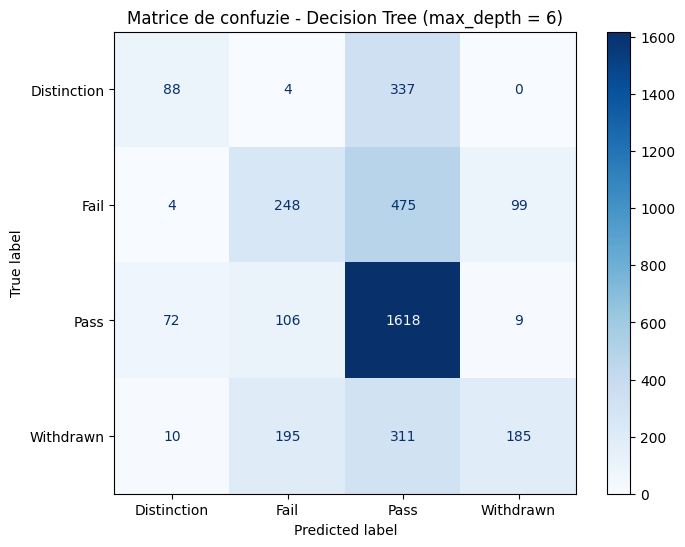

In [22]:
# Statistici pentru setul de validare
# Antrenez cel mai bun model găsit în urma experimentului
best_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
best_dt.fit(X_train, y_train)
y_pred_best = best_dt.predict(X_validate)

# Generez raportul de clasificare (Acuratețe, Precizie, Recall, F1)
print("Raport de clasificare pentru setul de validare (Cel mai bun model: max_depth = 6)")
raport = classification_report(y_validate, y_pred_best, target_names=le.classes_)
print(raport)

# Generez matricea de confuzie
cm = confusion_matrix(y_validate, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice de confuzie - Decision Tree (max_depth = 6)')
plt.show()

In [23]:
configs = [
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 5},
]

print("Experiment Random Forest")
for cfg in configs:
    rf = RandomForestClassifier(**cfg, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_validate)
    acc = accuracy_score(y_validate, y_pred)
    print(f"{cfg} -> Accuracy: {acc:.4f}")

Experiment Random Forest
{'n_estimators': 200, 'max_depth': 20} -> Accuracy: 0.5921
{'n_estimators': 300, 'max_depth': None} -> Accuracy: 0.5953
{'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 5} -> Accuracy: 0.5956


Raport de clasificare pentru setul de validare
              precision    recall  f1-score   support

 Distinction       0.60      0.22      0.32       429
        Fail       0.51      0.33      0.40       826
        Pass       0.61      0.91      0.73      1805
   Withdrawn       0.64      0.33      0.44       701

    accuracy                           0.60      3761
   macro avg       0.59      0.45      0.47      3761
weighted avg       0.59      0.60      0.55      3761



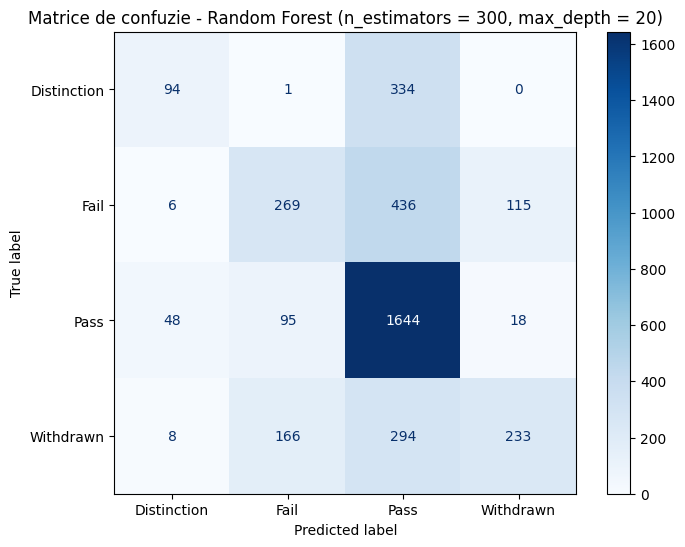

In [24]:
# Statistici pentru setul de validare
# Antrenez cel mai bun model găsit în urma experimentului 
best_rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_validate)

# Generez raportul de clasificare (Acuratețe, Precizie, Recall, F1)
print("Raport de clasificare pentru setul de validare")
raport = classification_report(y_validate, y_pred_best, target_names=le.classes_)
print(raport)

# Generez matricea de confuzie
cm = confusion_matrix(y_validate, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice de confuzie - Random Forest (n_estimators = 300, max_depth = 20)')
plt.show()

In [25]:
configs_lr = [
    {'C': 0.1, 'max_iter': 10000},
    {'C': 1.0, 'max_iter': 10000},
    {'C': 10.0, 'max_iter': 10000},
]

print("Experiment Logistic Regression (max_iter=10000)")
for cfg in configs_lr:
    lr = LogisticRegression(**cfg, random_state=42, solver='saga')
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_validate)
    acc = accuracy_score(y_validate, y_pred_lr)
    print(f"C={cfg['C']} -> Accuracy: {acc:.4f}")

Experiment Logistic Regression (max_iter=10000)
C=0.1 -> Accuracy: 0.6014
C=1.0 -> Accuracy: 0.6012
C=10.0 -> Accuracy: 0.6009


Raport de clasificare pentru setul de test
              precision    recall  f1-score   support

 Distinction       0.58      0.38      0.46       429
        Fail       0.52      0.35      0.42       826
        Pass       0.63      0.86      0.72      1805
   Withdrawn       0.58      0.38      0.46       701

    accuracy                           0.60      3761
   macro avg       0.58      0.49      0.51      3761
weighted avg       0.59      0.60      0.58      3761



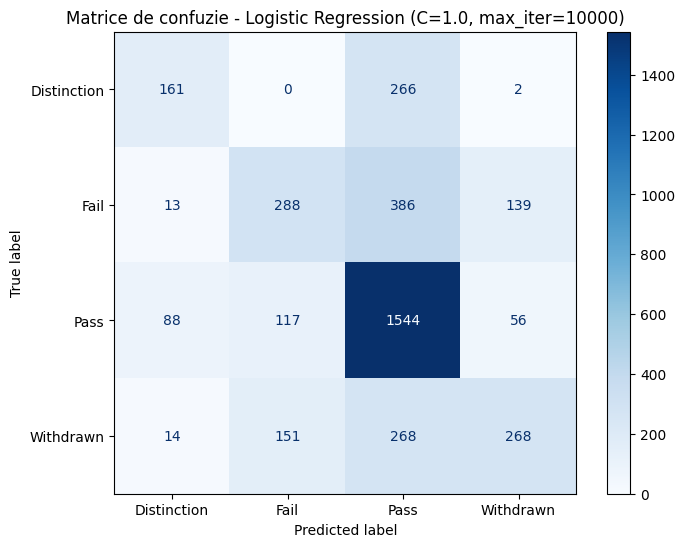

In [26]:
# Rezultatele pentru setul de validare
# Antrenez cel mai bun model găsit în urma experimentului
best_lr = LogisticRegression(C=1.0, max_iter=10000, random_state=42, solver='saga')
best_lr.fit(X_train, y_train)
y_pred_best = best_lr.predict(X_validate)

# Generez raportul de clasificare (Acuratețe, Precizie, Recall, F1)
print("Raport de clasificare pentru setul de test")
raport = classification_report(y_validate, y_pred_best, target_names=le.classes_)
print(raport)

# Generez matricea de confuzie
cm = confusion_matrix(y_validate, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice de confuzie - Logistic Regression (C=1.0, max_iter=10000)')
plt.show()

Raport de clasificare pentru setul de test
              precision    recall  f1-score   support

 Distinction       0.65      0.38      0.48       526
        Fail       0.49      0.35      0.41      1039
        Pass       0.62      0.86      0.72      2247
   Withdrawn       0.61      0.37      0.46       888

    accuracy                           0.60      4700
   macro avg       0.59      0.49      0.52      4700
weighted avg       0.59      0.60      0.58      4700



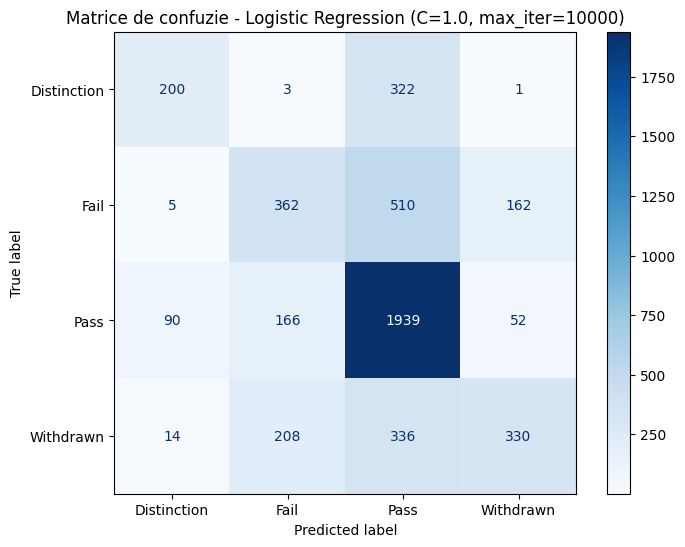

In [27]:
# Rezultatele pentru setul de test
# Antrenez cel mai bun model cu cel mai bun algoritm gasite in urma experimentului
lr = LogisticRegression(C=1.0, max_iter=10000, random_state=42, solver='saga')
lr.fit(X_train, y_train)
y_pred_best = lr.predict(X_test)

print("Raport de clasificare pentru setul de test")
raport = classification_report(y_test, y_pred_best, target_names=le.classes_)
print(raport)

# Generez matricea de confuzie
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice de confuzie - Logistic Regression (C=1.0, max_iter=10000)')
plt.show()

In [28]:
# Generez tabelul comparativ intre cele mai bune 3 modele gasite
models = {
    'Decision Tree (max_depth=6)': best_dt,
    'Random Forest (n=300, max_depth=20, min_samples_leaf=5)': best_rf,
    'Logistic Regression (C=1.0)': best_lr,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_validate)
    report = classification_report(y_validate, y_pred,
                                   target_names=le.classes_,
                                   output_dict=True)
    row = {'Model': name, 'Acuratete': round(report['accuracy'], 4)}
    for cls in le.classes_:
        row[f'{cls} - Precision'] = round(report[cls]['precision'], 4)
        row[f'{cls} - Recall'] = round(report[cls]['recall'], 4)
        row[f'{cls} - F1'] = round(report[cls]['f1-score'], 4)
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('Model')
display(comparison_df)

,Acuratete,Distinction - Precision,Distinction - Recall,Distinction - F1,Fail - Precision,Fail - Recall,Fail - F1,Pass - Precision,Pass - Recall,Pass - F1,Withdrawn - Precision,Withdrawn - Recall,Withdrawn - F1
Model,,,,,,,,,,,,,
Decision Tree (max_depth=6),0.5687,0.5057,0.2051,0.2919,0.4485,0.3002,0.3597,0.5903,0.8964,0.7118,0.6314,0.2639,0.3722
"Random Forest (n=300, max_depth=20, min_samples_leaf=5)",0.5956,0.6026,0.2191,0.3214,0.5066,0.3257,0.3965,0.6071,0.9108,0.7286,0.6366,0.3324,0.4367
Logistic Regression (C=1.0),0.6012,0.5833,0.3753,0.4567,0.5180,0.3487,0.4168,0.6266,0.8554,0.7234,0.5763,0.3823,0.4597


In [29]:
# Generez fisierele pentru submisia pe Kaggle
ids_class = kaggle_class_df['id'] if 'id' in kaggle_class_df.columns else range(1, len(kaggle_class_df) + 1)
if 'id' in X_kaggle_class.columns:
    X_kaggle_class = X_kaggle_class.drop(columns=['id'])

best_lr.fit(X_train, y_train)
y_pred_kaggle_class = best_lr.predict(X_kaggle_class)
y_pred_kaggle_labels = le.inverse_transform(y_pred_kaggle_class)

submission_class = pd.DataFrame({
    'id': ids_class,
    'prediction': y_pred_kaggle_labels
})
submission_class.to_csv('./output/submission_classification.csv', index=False)
print("Clasificare salvata!")
print(submission_class.head())

Clasificare salvata!
   id prediction
0   1       Pass
1   2       Pass
2   3       Pass
3   4       Pass
4   5       Pass


### 3.3. Regresie

In [30]:
# Pregatirea datelor pentru regresie
# Separam targetul de regresie
y_train_reg = train_split['final_coursework_score']
y_validate_reg = validate_split['final_coursework_score']
y_test_reg = test_df['final_coursework_score']

X_train_reg = X_train.copy()
X_validate_reg = X_validate.copy()
X_test_reg = X_test.copy()

In [31]:
# Functie pentru calculul metricilor
def eval_regression(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: MAE={mae:.2f} | MSE={mse:.2f} | RMSE={rmse:.2f} | R²={r2:.4f}")
    return {'Model': label, 'MAE': round(mae,2), 'MSE': round(mse,2), 
            'RMSE': round(rmse,2), 'R²': round(r2,4)}

In [32]:
# Antrenarea baseline-ului pentru regresie
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)

results = []
results.append(eval_regression(y_train_reg, lr_reg.predict(X_train_reg), 'LinearRegression - Train'))
results.append(eval_regression(y_validate_reg, lr_reg.predict(X_validate_reg), 'LinearRegression - Validate'))

LinearRegression - Train: MAE=5.05 | MSE=50.06 | RMSE=7.08 | R²=0.8250
LinearRegression - Validate: MAE=5.10 | MSE=50.63 | RMSE=7.12 | R²=0.8157


In [33]:
# Experiment cu variatia factorului de regularizare
alphas = [0.1, 1.0, 10.0, 100.0]
mae_train_ridge, mae_val_ridge = [], []
mae_train_lasso, mae_val_lasso = [], []

print("Experiment Ridge (L2)")
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_reg, y_train_reg)
    
    mae_train = mean_absolute_error(y_train_reg, ridge.predict(X_train_reg))
    mae_val = mean_absolute_error(y_validate_reg, ridge.predict(X_validate_reg))
    mse_val = mean_squared_error(y_validate_reg, ridge.predict(X_validate_reg))
    rmse = np.sqrt(mse_val)
    
    mae_train_ridge.append(mae_train)
    mae_val_ridge.append(mae_val)
    print(f"alpha={alpha} -> MAE={mae_val:.2f} | MSE={mse_val:.2f} | RMSE={rmse:.2f}")

print("\nExperiment Lasso (L1)")
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_reg, y_train_reg)
    
    mae_train = mean_absolute_error(y_train_reg, lasso.predict(X_train_reg))
    mae_val = mean_absolute_error(y_validate_reg, lasso.predict(X_validate_reg))
    mse_val = mean_squared_error(y_validate_reg, lasso.predict(X_validate_reg))
    rmse = np.sqrt(mse_val)
    
    mae_train_lasso.append(mae_train)
    mae_val_lasso.append(mae_val)
    print(f"alpha={alpha} -> MAE={mae_val:.2f} | MSE={mse_val:.2f} | RMSE={rmse:.2f}")

Experiment Ridge (L2)
alpha=0.1 -> MAE=5.10 | MSE=50.63 | RMSE=7.12
alpha=1.0 -> MAE=5.10 | MSE=50.63 | RMSE=7.12
alpha=10.0 -> MAE=5.10 | MSE=50.63 | RMSE=7.12
alpha=100.0 -> MAE=5.11 | MSE=50.64 | RMSE=7.12

Experiment Lasso (L1)
alpha=0.1 -> MAE=5.14 | MSE=51.39 | RMSE=7.17
alpha=1.0 -> MAE=5.50 | MSE=56.03 | RMSE=7.49
alpha=10.0 -> MAE=9.81 | MSE=149.98 | RMSE=12.25
alpha=100.0 -> MAE=13.16 | MSE=274.72 | RMSE=16.57


In [34]:
# Antrenez cel mai bun model si verific parametrii pentru setul de validare
ridge_val = Ridge(alpha=1.0)
ridge_val.fit(X_train_reg, y_train_reg)
mae_val = mean_absolute_error(y_validate_reg, ridge_val.predict(X_validate_reg))
mse_val = mean_squared_error(y_validate_reg, ridge_val.predict(X_validate_reg))
rmse = np.sqrt(mse_val)
print(f"alpha=1.0 -> MAE={mae_val:.2f} | MSE={mse_val:.2f} | RMSE={rmse:.2f}")

alpha=1.0 -> MAE=5.10 | MSE=50.63 | RMSE=7.12


In [35]:
# Antrenez cel mai bun model si verific parametrii pentru setul de test
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)
mae_val = mean_absolute_error(y_test_reg, ridge.predict(X_test_reg))
mse_val = mean_squared_error(y_test_reg, ridge.predict(X_test_reg))
rmse = np.sqrt(mse_val)
print(f"alpha=1.0 -> MAE={mae_val:.2f} | MSE={mse_val:.2f} | RMSE={rmse:.2f}")

alpha=1.0 -> MAE=5.12 | MSE=52.12 | RMSE=7.22


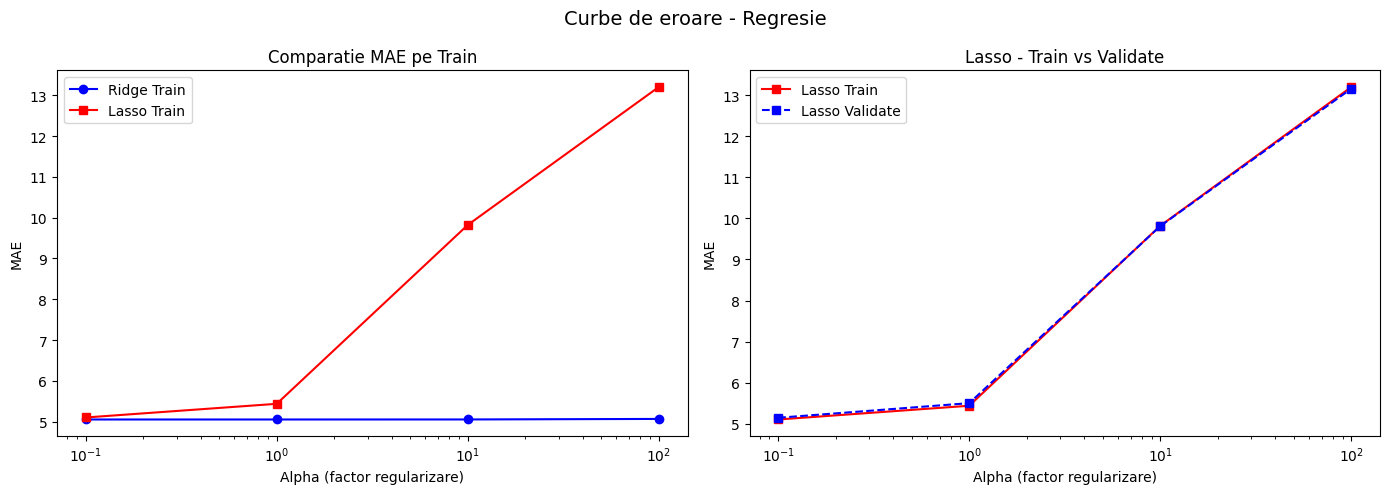

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#  Grafic 1 - Comparatie pe train
ax1.plot(alphas, mae_train_ridge, label='Ridge Train', marker='o', color='blue')
ax1.plot(alphas, mae_train_lasso, label='Lasso Train', marker='s', color='red')
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (factor regularizare)')
ax1.set_ylabel('MAE')
ax1.set_title('Comparatie MAE pe Train')
ax1.legend()

# Grafic 2 - Train vs validate pentru Lasso
ax2.plot(alphas, mae_train_lasso, label='Lasso Train', marker='s', color='red')
ax2.plot(alphas, mae_val_lasso, label='Lasso Validate', marker='s', 
         color='blue', linestyle='--')
ax2.set_xscale('log')
ax2.set_xlabel('Alpha (factor regularizare)')
ax2.set_ylabel('MAE')
ax2.set_title('Lasso - Train vs Validate')
ax2.legend()

plt.suptitle('Curbe de eroare - Regresie', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Generez tabelul comparativ intre metrici
results_table = []
results_table.append(eval_regression(y_validate_reg, lr_reg.predict(X_validate_reg), 'LinearRegression'))
results_table.append(eval_regression(y_validate_reg, ridge_val.predict(X_validate_reg), 'Ridge (alpha=1.0)'))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_reg, y_train_reg)
results_table.append(eval_regression(y_validate_reg, lasso.predict(X_validate_reg), 'Lasso (alpha=0.1)'))

results_df = pd.DataFrame(results_table).set_index('Model')
display(results_df)

LinearRegression: MAE=5.10 | MSE=50.63 | RMSE=7.12 | R²=0.8157
Ridge (alpha=1.0): MAE=5.10 | MSE=50.63 | RMSE=7.12 | R²=0.8157
Lasso (alpha=0.1): MAE=5.14 | MSE=51.39 | RMSE=7.17 | R²=0.8129


,MAE,MSE,RMSE,R²
Model,,,,
LinearRegression,5.10,50.63,7.12,0.8157
Ridge (alpha=1.0),5.10,50.63,7.12,0.8157
Lasso (alpha=0.1),5.14,51.39,7.17,0.8129


In [38]:
# Generez fisierele pentru submisia pe Kaggle
ids_reg = kaggle_reg_df['id'] if 'id' in kaggle_reg_df.columns else range(1, len(kaggle_reg_df) + 1)

if 'id' in X_kaggle_reg.columns:
    X_kaggle_reg = X_kaggle_reg.drop(columns=['id'])

ridge_final = Ridge(alpha=0.1)
ridge_final.fit(X_train_reg, y_train_reg)
y_pred_kaggle_reg = ridge_final.predict(X_kaggle_reg)

submission_reg = pd.DataFrame({
    'id': ids_reg,
    'prediction': y_pred_kaggle_reg
})
submission_reg.to_csv('./output/submission_regression.csv', index=False)
print("\nRegresie salvata!")
print(submission_reg.head())


Regresie salvata!
   id  prediction
0   1   71.429297
1   2   83.303953
2   3   73.211662
3   4   83.187272
4   5   84.220103
